# DEEP LEARNING

## Julián Alberto Uribe Gómez

# 2 - Modelos: RNN - LSTM - GRU

In [ ]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/2021.deeplearning/main/content/init.py
import init; init.init(force_download=False);

replicating local resources


In [ ]:
# Importar las librerias necesarias
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, GRU, SimpleRNN
import math
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [ ]:
# Importación del set de entrenamiento
# El set de datos se lee desde un archivo CSV, con 'Fecha_Hora' como índice y parseado como fechas.
dataset = pd.read_csv("https://raw.githubusercontent.com/algoritmomaestro/Proyecto_DeepLearning/refs/heads/main/datos_recaudo_total.csv", index_col='Fecha_Hora', parse_dates=['Fecha_Hora'])

# Verificación de valores faltantes
# El set de datos se ordena por índice (fecha).
dataset = dataset.sort_index()

# División del set de datos en sets de entrenamiento y prueba.
# El set de entrenamiento incluye datos hasta finales de 2022.
training_set = dataset[:'2022'].iloc[:,0:1].values
# El set de prueba incluye datos desde 2023 en adelante.
test_set = dataset['2023':].iloc[:,0:1].values

# Manejo de valores faltantes en el set de prueba reemplazándolos con el valor máximo de la columna 'Valor Pago' en todo el set de datos.
test_set[np.isnan(test_set)] = dataset['Valor Pago'].max()

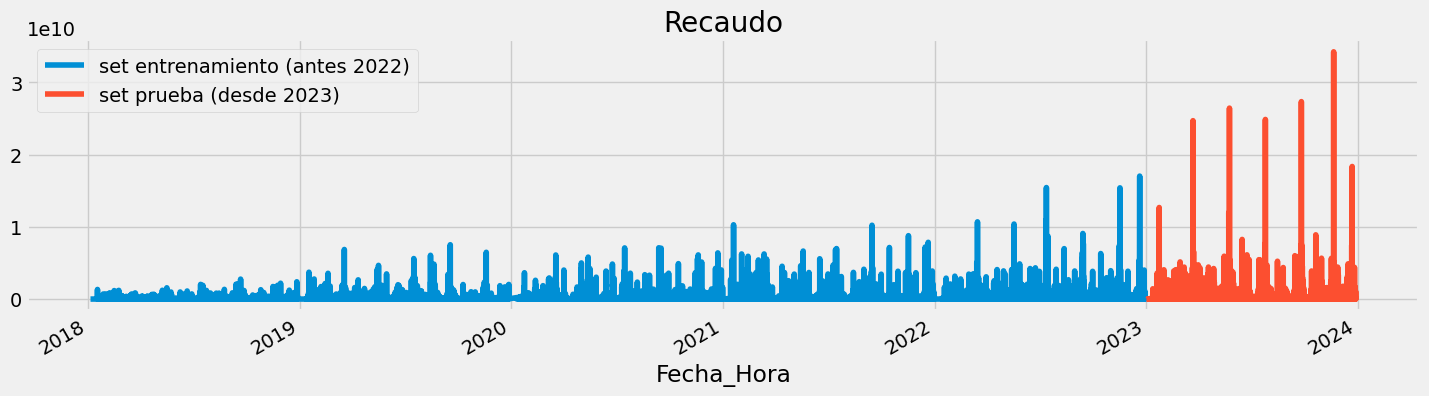

In [ ]:
# Gráfica del conjunto de recaudo en entrenamiento y prueba
dataset['Valor Pago'][:'2022'].plot(figsize=(16,4),legend=True)
dataset['Valor Pago']['2023':].plot(figsize=(16,4),legend=True)
plt.legend(['set entrenamiento (antes 2022)','set prueba (desde 2023)'])
plt.title('Recaudo')
plt.show()

In [ ]:
# Escala el set de entrenamiento usando MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
# Preparación de los datos de entrenamiento para RNN
# Importa la función create_dataset desde una biblioteca local.
from local.lib.DataPreparationRNN import create_dataset

# Define el número de pasos anteriores a considerar para la predicción.
look_back = 10

# Crea los sets de datos de entrenamiento X e y utilizando la función create_dataset.
# X_train contendrá las secuencias de entrada y y_train los valores objetivo.
X_train, y_train = create_dataset(training_set_scaled, look_back)

# Imprime las dimensiones de los sets de datos de entrenamiento.
print(X_train.shape)
print(y_train.shape)

(36870, 10)
(36870,)


# Modelos de redes neuronales artificiales

In [ ]:
# Selecciona el tipo de modelo, unidades, épocas y dropout
model_type = "LSTM" # @param ["RNN","LSTM","GRU"]
units = 3 # @param {"type":"slider","min":0,"max":100,"step":1}
epochs = 5 # @param {"type":"slider","min":0,"max":200,"step":1}
Dropout = 0.3 # @param {"type":"slider","min":0,"max":0.9,"step":0.1}

# Construye el modelo basado en la selección
if model_type == 'RNN':
    # Modelo RNN simple
    model = Sequential()
    model.add(SimpleRNN(units=units,input_shape=(X_train.shape[1],1)))
    model.add(Dropout(Dropout))
    model.add(Dense(units=1))

    # Muestra el resumen del modelo
    model.summary()

    # Compila el modelo
    model.compile(optimizer='adam',loss='mean_squared_error')
    # Entrena el modelo
    model.fit(X_train.reshape(X_train.shape[0],look_back,1),y_train,epochs=epochs,batch_size=32)

elif model_type == 'LSTM':
    # Modelo LSTM
    model = Sequential()
    model.add(LSTM(units=units, input_shape=(X_train.shape[1],1)))
    model.add(Dropout(Dropout))
    model.add(Dense(units=1))

    # Muestra el resumen del modelo
    model.summary()

    # Compila el modelo
    model.compile(optimizer='adam',loss='mean_squared_error')
    # Entrena el modelo
    model.fit(X_train.reshape(X_train.shape[0],look_back,1),y_train,epochs=epochs,batch_size=32)

elif model_type == 'GRU':
    # Modelo GRU
    model = Sequential()
    model.add(GRU(units=units, input_shape=(X_train.shape[1],1)))
    model.add(Dropout(Dropout))
    model.add(Dense(units=1))

    # Muestra el resumen del modelo
    model.summary()

    # Compila el modelo
    model.compile(optimizer='adam',loss='mean_squared_error')
    # Entrena el modelo
    model.fit(X_train.reshape(X_train.shape[0],look_back,1),y_train,epochs=epochs,batch_size=32)

else:
    # Lanza un error si el tipo de modelo no es válido
    raise ValueError("model_type debe ser 'RNN', 'LSTM' o 'GRU'.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 15)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,036 (4.05 KB)

 Trainable params: 1,036 (4.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 5.8354e-04
Epoch 2/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 6.1015e-04
Epoch 3/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 5.5228e-04
Epoch 4/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 6.7648e-04
Epoch 5/5
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 5.1553e-04


### Predicción del modelo

In [ ]:
# Concatena los sets de datos de entrenamiento y prueba para preparar los datos de entrada para la predicción.
dataset_total = pd.concat((dataset['Valor Pago'][:'2022'],dataset['Valor Pago']['2023':]),axis=0)
# Selecciona los últimos 'look_back' + longitud del set de prueba para usar como entrada.
inputs = dataset_total[len(dataset_total)-len(test_set) - look_back:].values
# Maneja los valores faltantes reemplazándolos con el valor máximo de la columna 'Valor Pago'.
inputs[np.isnan(inputs)] = dataset['Valor Pago'].max()
# Redimensiona los datos de entrada a un formato de columna.
inputs = inputs.reshape(-1,1)
# Escala los datos de entrada usando el mismo escalador ajustado en el set de entrenamiento.
inputs  = sc.transform(inputs)
# Imprime la forma de los datos de entrada.
inputs.shape

(7812, 1)

In [ ]:
# Prepara los datos de prueba para la predicción.
X_test = []
# Itera sobre los datos de entrada para crear secuencias de tamaño 'look_back'.
for i in range(look_back,inputs.shape[0]):
    X_test.append(inputs[i-look_back:i,0])
# Convierte la lista a un array de numpy.
X_test = np.array(X_test)
# Redimensiona el array para que sea compatible con el modelo RNN (muestras, pasos de tiempo, características).
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
# Realiza las predicciones utilizando el modelo entrenado.
predicted = model.predict(X_test)
# Invierte el escalado de las predicciones para obtener los valores originales.
predicted = sc.inverse_transform(predicted)

244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


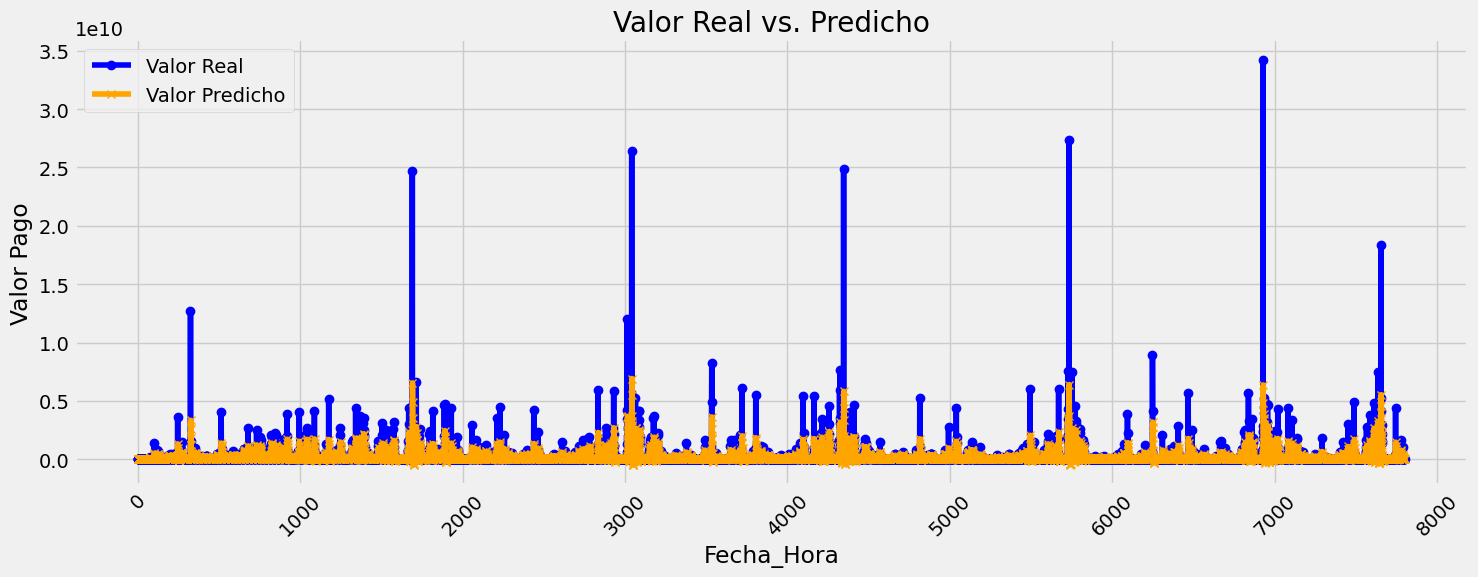

In [ ]:
# Gráfica de los resultados de la predicción
plt.figure(figsize=(15, 6))
plt.plot(test_set, color='blue', label='Valor Real', marker='o')
plt.plot(predicted, color='orange',label='Valor Predicho', marker='x')

plt.title(f'Valor Real vs. Predicho')
plt.xlabel('Fecha_Hora')
plt.ylabel('Valor Pago')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Evaluación del modelo

In [ ]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calcula la raíz del error cuadrático medio (RMSE).
rmse = math.sqrt(mean_squared_error(test_set, predicted))
print("RMSE {}.".format(rmse))

# Define la función para calcular el Error Porcentual Absoluto Medio (MAPE).
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calcula el MAPE.
mape = mean_absolute_percentage_error(test_set, predicted)
print("MAPE {}.".format(mape))

# Calcula el Error Absoluto Medio (MAE).
mae = mean_absolute_error(test_set, predicted)
print("MAE {}.".format(mae))

# Define la función para calcular el Error Porcentual Absoluto Medio Escalonado Simétrico (sMAPE).
def smape(y_true, y_pred):
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

# Calcula el sMAPE.
smape_value = smape(test_set, predicted)
print("sMAPE {}.".format(smape_value))

# Define la función para calcular el Error Escalonado Medio Absoluto (MASE).
def mase(y_true, y_pred, training_set):
    numerator = np.mean(np.abs(y_true - y_pred))
    denominator = np.mean(np.abs(training_set[1:] - training_set[:-1]))
    return numerator / denominator

# Calcula el MASE.
mase_value = mase(test_set, predicted, training_set)
print("MASE {}.".format(mase_value))

# Calcula el coeficiente de determinación (R-squared).
r2 = r2_score(test_set, predicted)
print("R-squared {}.".format(r2))

RMSE 888718973.9147031.
MAPE 174584.9302903142.
MAE 216822573.77025923.
sMAPE 111.88470597172883.
MASE 1.8126443220755464.
R-squared 0.18441425027464198.
